In [5]:
from sage.all import *

D = delta_qexp(2800) 
h=[1]+[D[k] for k in range(1,101)]
print(h)

[1, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920, 534612, -370944, -577738, 401856, 1217160, 987136, -6905934, 2727432, 10661420, -7109760, -4219488, -12830688, 18643272, 21288960, -25499225, 13865712, -73279080, 24647168, 128406630, -29211840, -52843168, -196706304, 134722224, 165742416, -80873520, 167282496, -182213314, -255874080, -145589976, 408038400, 308120442, 101267712, -17125708, -786948864, -548895690, -447438528, 2687348496, 248758272, -1696965207, 611981400, -1740295368, 850430336, -1596055698, 1758697920, 2582175960, -1414533120, 2686677840, -3081759120, -5189203740, -1791659520, 6956478662, 1268236032, 1902838392, 2699296768, -2790474540, -3233333376, -15481826884, 10165534848, 4698104544, 1940964480, 9791485272, -9600560640, 1463791322, 4373119536, -6425804700, -15693610240, -8951543328, 3494159424, 38116845680, 4767866880, 1665188361, -7394890608, -29335099668, 6211086336, -33355661220, 411016992, 32358470760, 45164021760, -24992917110, 13173496560, 

In [6]:
print(nth_prime(420))

2903


In [7]:
from sage.all import *

D = delta_qexp(2800) 
h=[1]+[D[nth_prime(k)] for k in range(1,401)]
print(h)

[1, -24, 252, 4830, -16744, 534612, -577738, -6905934, 10661420, 18643272, 128406630, -52843168, -182213314, 308120442, -17125708, 2687348496, -1596055698, -5189203740, 6956478662, -15481826884, 9791485272, 1463791322, 38116845680, -29335099668, -24992917110, 75013568546, 81742959102, -225755128648, 90241258356, 73482676310, -85146862638, -262717201024, 631528759932, -297198746214, 596793577940, -1115433620850, -824447297848, 1315116754406, -357832759588, 2754833892216, -950387449578, 1681384224780, -996774496018, 2762403350592, 5442387685442, -2876091504354, 728391402200, -6793168439188, 7334863021472, -1359839565924, -11824411223170, -17563353448518, -7139577462960, -231306909358, 12983053545252, 23961192565506, -24273728464488, 25837706543670, -3767932360528, -16418932005874, 21035722907082, 16713176326532, -23926858987458, 15311092828556, 49875160575912, -99480832756438, 83369248359366, -63584021925868, 121001428335986, -155661561078204, -25643022194650, 24909815245602, 15758415085

j: 50
j: 100
j: 150
j: 200
j: 250
j: 300
j: 350
j: 400
main block 2
main block 3
main block 4
main block 5
main block 6
main block 7
main block 8
main block 9
main block 10
main block 11
main block 12
main block 13
main block 14
main block 15
main block 16
main block 17
main block 18
main block 19
main block 20
main block 21
main block 22
main block 23
main block 24
main block 25
main block 26
main block 27
main block 28
main block 29
main block 30
main block 31
main block 32
main block 33
main block 34
main block 35
main block 36
main block 37
main block 38
main block 39
main block 40
main block 41
main block 42
main block 43
main block 44
main block 45
main block 46
main block 47
main block 48
main block 49
main block 50
main block 51
main block 52
main block 53
main block 54
main block 55
main block 56
main block 57
main block 58
main block 59
main block 60
main block 61
main block 62
main block 63
main block 64
main block 65
main block 66
main block 67
main block 68
main block 69
m

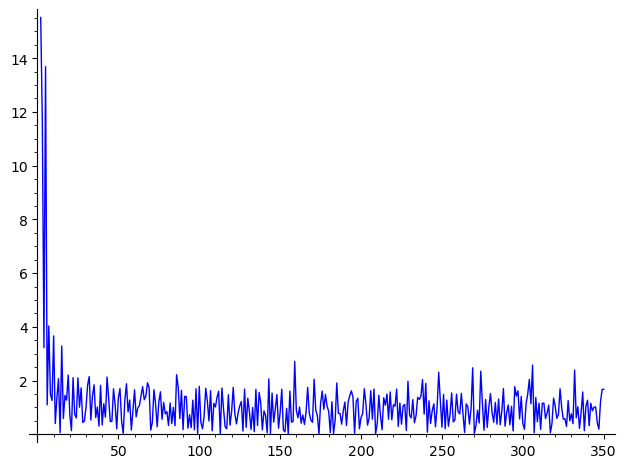

NameError: name 'charpol_list_list' is not defined

In [1]:
from sage.all import *
import pickle

D = delta_qexp(3000) 
h_list=[1]+[D[nth_prime(k)] for k in range(1,405)]
c = 1
j_list=[(0,c)]

for n in range(1,401):
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    j_list.append((n,j_n))
    if n%50==0:
        print("j:",n)

with open('/Users/barrybrent/data2/run6april26no11.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile)
    
def P_matrix(lst):
   
    lenlist = len(lst)
    columns = []
    
    
    columns.append(lst)
    
   
    for k in range(1, lenlist):
        column = [0] * (k - 1) + [-k]
        column = flatten(column + [lst])
        column = column[:lenlist]
        columns.append(column)
    
    return matrix(columns).transpose()

precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)
charpol_list = []
roots_list = []
mins_list = []
for n in range(2, 351): 
    print("main block",n)
    j_vals=[pair[1] for pair in j_list]
    pl = P_matrix(j_vals[1:n+1])#<<<<<<<<<<<<<<<<<<<<<< undeformed
    cp = pl.charpoly()
    charpol_list.append((n, cp))
    roots = cp.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))
        

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

with open('/Users/barrybrent/data2/run6april26no12.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile)
with open('/Users/barrybrent/data2/run6april26no13.txt', 'wb') as wfile:
    pickle.dump(charpol_list_list, wfile)
with open('/Users/barrybrent/data2/run6april26no14.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)



In [2]:
with open('/Users/barrybrent/data2/run6april26no14.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)